# 01. Raw data plots

Reduced A1 task for the teammate: inspect all 322 samples by protocol, then inspect the Velasco subset by publication.

## Step 1. Load the working dataset

This notebook is self-contained, so it imports its own packages and reads the working CSV even though the A2 notebook used the same data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

df_all = pd.read_csv(DATA / "hnoca_sample_composition.csv")
print("Project root:", ROOT)
print("Dataset shape:", df_all.shape)

Project root: d:\Hackathon\organoid-growth-charts
Dataset shape: (322, 28)


## Step 2. Count samples per protocol

Protocols with at least seven samples receive their own colour in the all-sample plot. Smaller protocols remain in the dataset but are combined into one `other` display group.

In [2]:
protocol_counts = (
    df_all["protocol"]
    .value_counts()
    .rename_axis("protocol")
    .reset_index(name="n_samples")
)
protocol_counts["protocol_short"] = protocol_counts["protocol"].str.replace(
    r"\s*\(doi:[^)]+\)", "", regex=True
)
protocol_counts["plot_group"] = np.where(
    protocol_counts["n_samples"] >= 7,
    protocol_counts["protocol_short"],
    "other",
)

n_large_protocols = int((protocol_counts["n_samples"] >= 7).sum())
n_small_protocols = int((protocol_counts["n_samples"] < 7).sum())
n_other_samples = int(protocol_counts.loc[protocol_counts["n_samples"] < 7, "n_samples"].sum())

print("Total protocols:", len(protocol_counts))
print("Protocols with at least 7 samples:", n_large_protocols)
print("Protocols combined as other:", n_small_protocols)
print("Samples in other:", n_other_samples)
protocol_counts

Total protocols: 27
Protocols with at least 7 samples: 8
Protocols combined as other: 19
Samples in other: 54


,protocol,n_samples,protocol_short,plot_group
0,"Velasco, 2019 (doi: 10.1038/s41586-019-1289-x)",131,"Velasco, 2019","Velasco, 2019"
1,"Lancaster, 2014 (doi: 10.1038/nprot.2014.158)",81,"Lancaster, 2014","Lancaster, 2014"
2,"Yoon, 2019 (doi: 10.1038/s41592-018-0255-0)",17,"Yoon, 2019","Yoon, 2019"
3,"Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0)...",9,"Bhaduri, 2020; directed","Bhaduri, 2020; directed"
4,"Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0)...",8,"Bhaduri, 2020; most directed","Bhaduri, 2020; most directed"
5,"Quadrato, 2017 (doi: 10.1038/protex.2017.049)",8,"Quadrato, 2017","Quadrato, 2017"
6,"Jo et al., 2016 (doi: 10.1016/j.stem.2016.07.005)",7,"Jo et al., 2016","Jo et al., 2016"
7,"Qian et al., 2016 (doi: 10.1016/j.cell.2016.04...",7,"Qian et al., 2016","Qian et al., 2016"
8,"Pasca, 2015 (doi: 10.1038/nmeth.3415)",5,"Pasca, 2015",other
9,"Huang, 2021 (doi: 10.1016/j.stem.2021.04.006)",5,"Huang, 2021",other


## Step 3. Plot all samples by protocol

This overview compares protocol-specific age coverage and NPC/IP cell percentages. It is descriptive only: different protocols are not pooled into one growth chart.

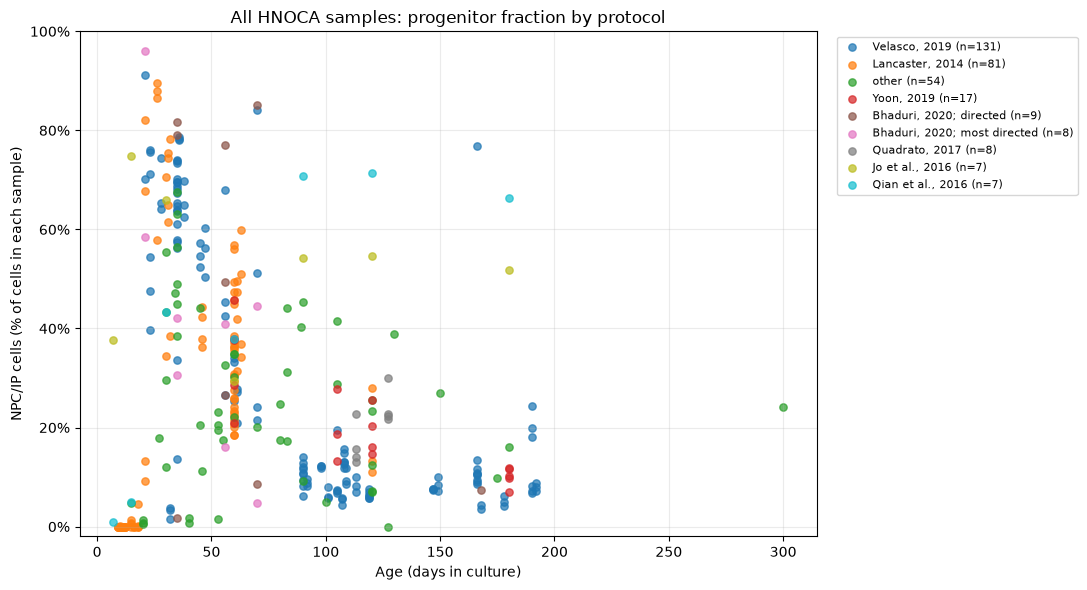

In [3]:
protocol_to_group = protocol_counts.set_index("protocol")["plot_group"]
plot_all = df_all.copy()
plot_all["protocol_group"] = plot_all["protocol"].map(protocol_to_group)
assert plot_all["protocol_group"].notna().all()

group_order = plot_all["protocol_group"].value_counts().index.tolist()
group_colors = plt.cm.tab10(np.linspace(0, 1, len(group_order)))

fig_all, ax = plt.subplots(figsize=(11, 6))
for group_name, color in zip(group_order, group_colors):
    group = plot_all[plot_all["protocol_group"] == group_name]
    ax.scatter(
        group["age"], group["frac_NPC_IP"],
        s=28, alpha=0.72, color=color,
        label=f"{group_name} (n={len(group)})",
    )

ax.set(
    xlabel="Age (days in culture)",
    ylabel="NPC/IP cells (% of cells in each sample)",
    title="All HNOCA samples: progenitor fraction by protocol",
    ylim=(-0.02, 1.0),
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.grid(alpha=0.25)
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Step 4. Plot the Velasco protocol by publication

The Velasco protocol contains 131 samples from four publications. Publication colours reveal age coverage and possible source-specific offsets without treating protocol and publication as the same variable.

                n_samples  age_min_days  age_max_days  npc_ip_mean  \
publication                                                          
Bhaduri, 2020          17            21           168        0.420   
Paulsen, 2022          54            28           190        0.321   
Uzquiano, 2022         39            23           192        0.310   
Velasco, 2019          21           101           190        0.142   

                npc_ip_median  
publication                    
Bhaduri, 2020           0.426  
Paulsen, 2022           0.124  
Uzquiano, 2022          0.254  
Velasco, 2019           0.101  


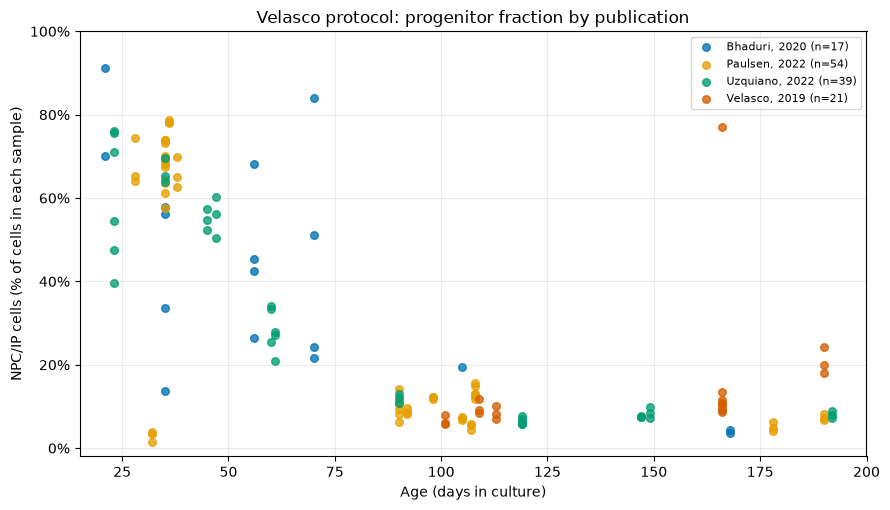

In [4]:
velasco = df_all[df_all["protocol"].str.contains("Velasco", case=False, na=False)].copy()

velasco_publication_summary = (
    velasco.groupby("publication")
    .agg(
        n_samples=("sample", "size"),
        age_min_days=("age", "min"),
        age_max_days=("age", "max"),
        npc_ip_mean=("frac_NPC_IP", "mean"),
        npc_ip_median=("frac_NPC_IP", "median"),
    )
    .sort_index()
)
print(velasco_publication_summary.round(3))

publication_colors = {
    "Bhaduri, 2020": "#0072B2",
    "Paulsen, 2022": "#E69F00",
    "Uzquiano, 2022": "#009E73",
    "Velasco, 2019": "#D55E00",
}

fig_velasco, ax = plt.subplots(figsize=(9, 5.2))
for publication, group in velasco.groupby("publication"):
    ax.scatter(
        group["age"], group["frac_NPC_IP"],
        s=30, alpha=0.78, color=publication_colors[publication],
        label=f"{publication} (n={len(group)})",
    )

ax.set(
    xlabel="Age (days in culture)",
    ylabel="NPC/IP cells (% of cells in each sample)",
    title="Velasco protocol: progenitor fraction by publication",
    xlim=(15, 200),
    ylim=(-0.02, 1.0),
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Initial Velasco NPC/IP interpretation

The unadjusted Bhaduri, 2020 mean and median NPC/IP percentages are the highest, while Velasco, 2019 is the lowest. This is not sufficient evidence of a publication batch effect because publication and age are confounded: Velasco, 2019 contains only day 101 to day 190 samples. Within overlapping ages, Bhaduri appears higher than Uzquiano for some day 55 to day 75 samples, so an age-adjusted publication effect remains plausible. A day 70 Bhaduri test sample near 84% NPC/IP produces the largest positive baseline z-score, while a day 166 Velasco train sample near 77% NPC/IP inflates the late rolling-window p95.

## Step 5. Save the first two A1 figures

Save the all-sample protocol overview and the Velasco NPC/IP plot before adding the remaining full A1 outputs.

In [5]:
FIGURES.mkdir(parents=True, exist_ok=True)
all_protocols_path = FIGURES / "raw_all_protocols.png"
velasco_publication_path = FIGURES / "raw_velasco_publication.png"

fig_all.savefig(all_protocols_path, dpi=150, bbox_inches="tight")
fig_velasco.savefig(velasco_publication_path, dpi=150, bbox_inches="tight")

assert all_protocols_path.exists() and all_protocols_path.stat().st_size > 0
assert velasco_publication_path.exists() and velasco_publication_path.stat().st_size > 0

print(f"All protocols: {all_protocols_path} | {all_protocols_path.stat().st_size:,} bytes")
print(f"Velasco publications: {velasco_publication_path} | {velasco_publication_path.stat().st_size:,} bytes")

All protocols: d:\Hackathon\organoid-growth-charts\figures\raw_all_protocols.png | 153,524 bytes
Velasco publications: d:\Hackathon\organoid-growth-charts\figures\raw_velasco_publication.png | 88,018 bytes


## Step 6. Save the publication sample-count and age-range table

This descriptive table uses all 322 samples. For each publication, it records the number of samples and the minimum and maximum culture age in days. It helps reveal unequal sample sizes and unequal age coverage before comparing publications.

In [6]:
publication_summary = (
    df_all.groupby("publication", dropna=False)
    .agg(
        n_samples=("sample", "size"),
        age_min_days=("age", "min"),
        age_max_days=("age", "max"),
    )
    .reset_index()
    .sort_values(["n_samples", "publication"], ascending=[False, True])
    .reset_index(drop=True)
)

RESULTS.mkdir(parents=True, exist_ok=True)
summary_path = RESULTS / "data_summary.csv"
publication_summary.to_csv(summary_path, index=False)

assert publication_summary["n_samples"].sum() == len(df_all)
assert summary_path.exists() and summary_path.stat().st_size > 0

print(f"Publications: {len(publication_summary)}")
print(f"Samples represented: {publication_summary['n_samples'].sum()} samples")
print(f"Saved: {summary_path} | {summary_path.stat().st_size:,} bytes")
publication_summary

Publications: 27
Samples represented: 322 samples
Saved: d:\Hackathon\organoid-growth-charts\results\data_summary.csv | 739 bytes


,publication,n_samples,age_min_days,age_max_days
0,"Paulsen, 2022",54,28,190
1,"Uzquiano, 2022",47,23,192
2,"Bhaduri, 2020",34,21,168
3,"Fleck, 2022",34,9,61
4,"Kanton, 2019",29,10,120
5,"Velasco, 2019",21,101,190
6,"He, 2022",18,15,63
7,"Bowles, 2021",14,60,180
8,"Treutlein, 2023",14,7,180
9,"Fiorenzano, 2021",7,15,120


## Step 7. Plot Velasco neuron and glia fractions by publication

These two plots complete the three requested Velasco outcomes. Each point is one sample. The x-axis is culture age in days, and the y-axis is the percentage of cells classified as neurons or glia. The legend reports the number of non-missing measurements actually plotted for each publication.

Non-missing Velasco measurements (samples):
                n_neuron  n_glia
publication                     
Bhaduri, 2020         17      17
Paulsen, 2022         54      54
Uzquiano, 2022        39      39
Velasco, 2019         21      21
Saved: d:\Hackathon\organoid-growth-charts\figures\raw_velasco_neuron.png | 89,655 bytes


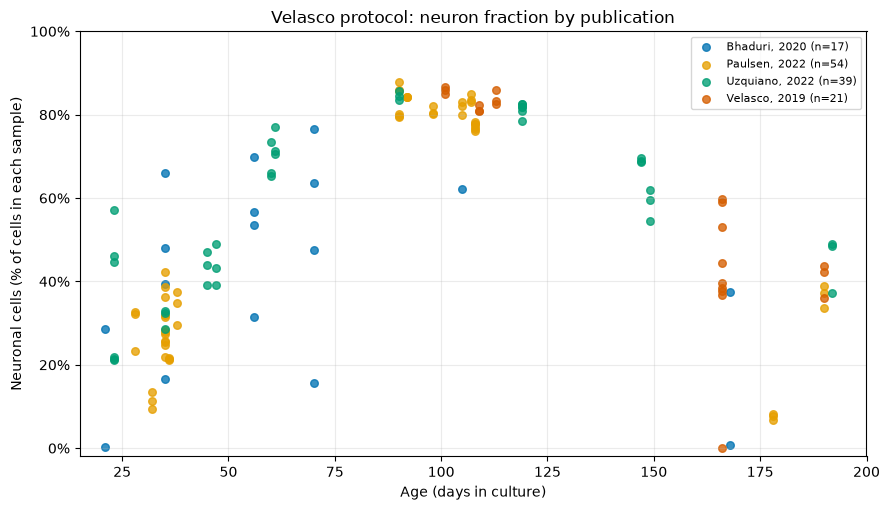

Saved: d:\Hackathon\organoid-growth-charts\figures\raw_velasco_glia.png | 74,270 bytes


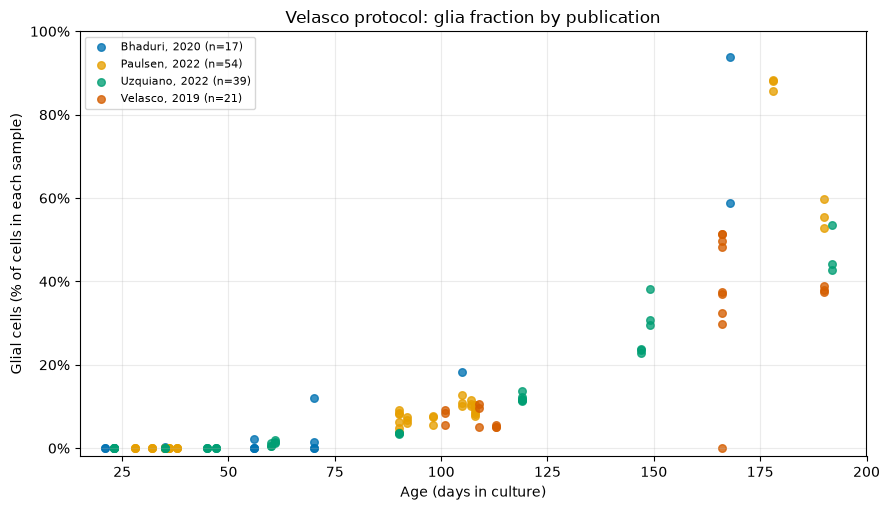

In [7]:
def plot_fraction_by_publication(
    data, value_column, y_label, title, output_path, color_map=None, xlim=None
):
    fig, ax = plt.subplots(figsize=(9, 5.2))

    for publication, group in data.groupby("publication"):
        observed = group.dropna(subset=[value_column])
        if observed.empty:
            continue

        scatter_options = {}
        if color_map is not None and publication in color_map:
            scatter_options["color"] = color_map[publication]

        ax.scatter(
            observed["age"], observed[value_column],
            s=30, alpha=0.78,
            label=f"{publication} (n={len(observed)})",
            **scatter_options,
        )

    ax.set(
        xlabel="Age (days in culture)",
        ylabel=y_label,
        title=title,
        ylim=(-0.02, 1.0),
    )
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    plt.tight_layout()

    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    assert output_path.exists() and output_path.stat().st_size > 0
    print(f"Saved: {output_path} | {output_path.stat().st_size:,} bytes")
    plt.show()
    return fig


velasco_measurement_counts = (
    velasco.groupby("publication")[["frac_neuron", "frac_glia"]]
    .count()
    .rename(columns={"frac_neuron": "n_neuron", "frac_glia": "n_glia"})
)
print("Non-missing Velasco measurements (samples):")
print(velasco_measurement_counts)

fig_velasco_neuron = plot_fraction_by_publication(
    velasco,
    value_column="frac_neuron",
    y_label="Neuronal cells (% of cells in each sample)",
    title="Velasco protocol: neuron fraction by publication",
    output_path=FIGURES / "raw_velasco_neuron.png",
    color_map=publication_colors,
    xlim=(15, 200),
)

fig_velasco_glia = plot_fraction_by_publication(
    velasco,
    value_column="frac_glia",
    y_label="Glial cells (% of cells in each sample)",
    title="Velasco protocol: glia fraction by publication",
    output_path=FIGURES / "raw_velasco_glia.png",
    color_map=publication_colors,
    xlim=(15, 200),
)

## Step 8. Plot the Lancaster protocol by publication

The Lancaster protocol contains 81 samples from three publications. The following table checks sample counts, culture-age coverage and non-missing measurements. Three separate plots then show NPC/IP, neuron and glia fractions using the same visual rules as the Velasco plots.

Lancaster protocol summary:
              n_samples  age_min_days  age_max_days  n_npc_ip  n_neuron  \
publication                                                               
Fleck, 2022          34             9            61        34        34   
He, 2022             18            15            63        18        18   
Kanton, 2019         29            10           120        29        29   

              n_glia  
publication           
Fleck, 2022       34  
He, 2022          18  
Kanton, 2019      29  
Saved: d:\Hackathon\organoid-growth-charts\figures\raw_lancaster_npc_ip.png | 66,423 bytes


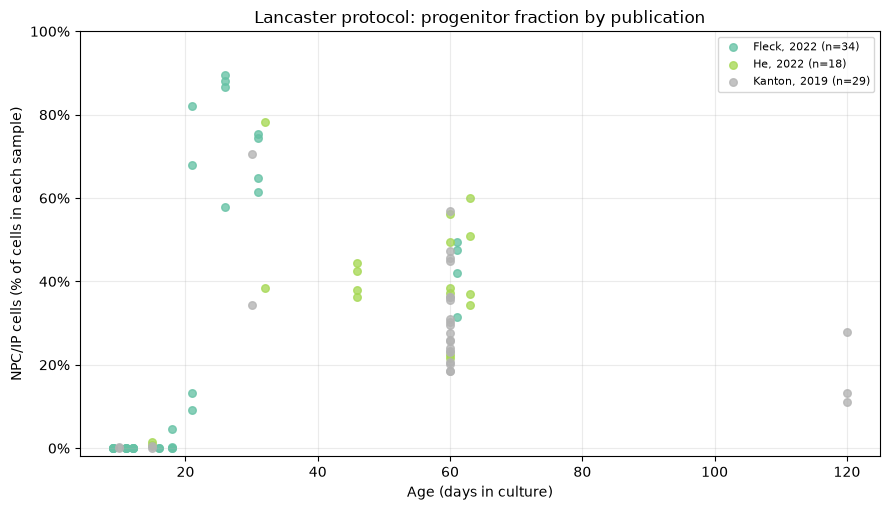

Saved: d:\Hackathon\organoid-growth-charts\figures\raw_lancaster_neuron.png | 66,226 bytes


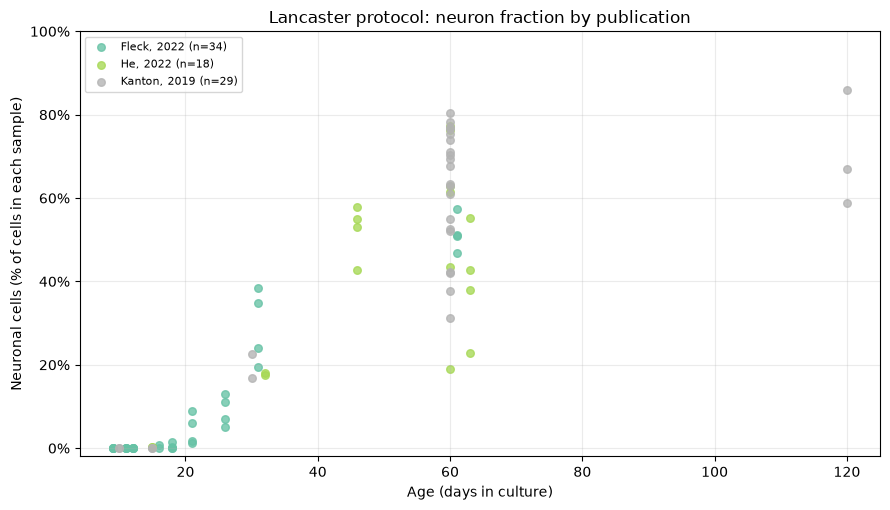

Saved: d:\Hackathon\organoid-growth-charts\figures\raw_lancaster_glia.png | 49,779 bytes


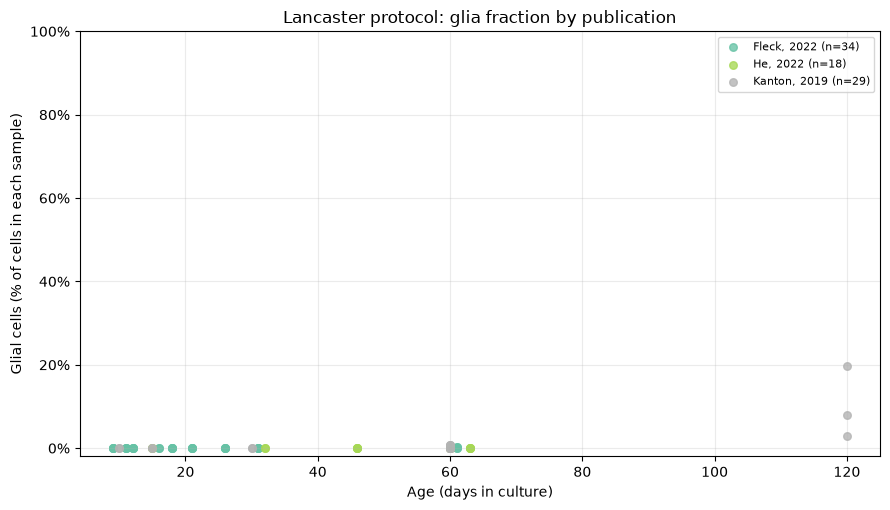

In [8]:
lancaster = df_all[
    df_all["protocol"].str.contains("Lancaster", case=False, na=False)
].copy()

assert len(lancaster) == 81

lancaster_publication_summary = (
    lancaster.groupby("publication")
    .agg(
        n_samples=("sample", "size"),
        age_min_days=("age", "min"),
        age_max_days=("age", "max"),
        n_npc_ip=("frac_NPC_IP", "count"),
        n_neuron=("frac_neuron", "count"),
        n_glia=("frac_glia", "count"),
    )
    .sort_index()
)
print("Lancaster protocol summary:")
print(lancaster_publication_summary)

lancaster_publications = sorted(lancaster["publication"].dropna().unique())
lancaster_palette = plt.cm.Set2(np.linspace(0, 1, len(lancaster_publications)))
lancaster_colors = dict(zip(lancaster_publications, lancaster_palette))
lancaster_xlim = (
    max(0, lancaster["age"].min() - 5),
    lancaster["age"].max() + 5,
)

fig_lancaster_npc_ip = plot_fraction_by_publication(
    lancaster,
    value_column="frac_NPC_IP",
    y_label="NPC/IP cells (% of cells in each sample)",
    title="Lancaster protocol: progenitor fraction by publication",
    output_path=FIGURES / "raw_lancaster_npc_ip.png",
    color_map=lancaster_colors,
    xlim=lancaster_xlim,
)

fig_lancaster_neuron = plot_fraction_by_publication(
    lancaster,
    value_column="frac_neuron",
    y_label="Neuronal cells (% of cells in each sample)",
    title="Lancaster protocol: neuron fraction by publication",
    output_path=FIGURES / "raw_lancaster_neuron.png",
    color_map=lancaster_colors,
    xlim=lancaster_xlim,
)

fig_lancaster_glia = plot_fraction_by_publication(
    lancaster,
    value_column="frac_glia",
    y_label="Glial cells (% of cells in each sample)",
    title="Lancaster protocol: glia fraction by publication",
    output_path=FIGURES / "raw_lancaster_glia.png",
    color_map=lancaster_colors,
    xlim=lancaster_xlim,
)

## Step 9. Interpret the full A1 atlas and verify outputs

### Interpretation

Across both protocols, raw cell composition changes strongly with culture age. In the Velasco protocol, NPC/IP cells generally fall from high early percentages to roughly 5% to 15% after about day 90, neuronal cells are commonly around 75% to 88% from about day 90 to day 120, and glial cells become more prominent at later ages. In the Lancaster protocol, NPC/IP cells rise sharply around day 20 to day 30, neuronal cells increase across the observed age range, and glial cells remain near 0% through roughly day 65 except for later Kanton samples at day 120.

Within the Velasco protocol, the unadjusted Bhaduri, 2020 mean and median NPC/IP percentages are the highest, while Velasco, 2019 is the lowest. This does not prove a publication batch effect because publication and age are confounded: Velasco, 2019 contains only day 101 to day 190 samples. Within overlapping ages, Bhaduri appears higher than Uzquiano for some day 55 to day 75 samples, so an age-adjusted publication effect remains plausible. The raw plots are descriptive evidence only; they motivate later age-adjusted batch-effect modelling.

The Lancaster comparison has the same limitation. Fleck and He end near day 61 to day 63, whereas only Kanton extends to day 120. The later Kanton neuron and glia values therefore cannot be separated from age using these raw plots alone.

In [9]:
expected_outputs = [
    ("table", RESULTS / "data_summary.csv"),
    ("figure", FIGURES / "raw_all_protocols.png"),
    ("figure", FIGURES / "raw_velasco_publication.png"),
    ("figure", FIGURES / "raw_velasco_neuron.png"),
    ("figure", FIGURES / "raw_velasco_glia.png"),
    ("figure", FIGURES / "raw_lancaster_npc_ip.png"),
    ("figure", FIGURES / "raw_lancaster_neuron.png"),
    ("figure", FIGURES / "raw_lancaster_glia.png"),
]

assert len(df_all) == 322
assert len(velasco) == 131
assert len(lancaster) == 81
assert publication_summary["n_samples"].sum() == 322
assert all(path.exists() and path.stat().st_size > 0 for _, path in expected_outputs)

output_manifest = pd.DataFrame(
    [
        {
            "output_type": output_type,
            "path": str(path),
            "size_bytes": path.stat().st_size,
        }
        for output_type, path in expected_outputs
    ]
)
print("A1 validation passed: 322 total samples, 131 Velasco samples, 81 Lancaster samples.")
output_manifest

A1 validation passed: 322 total samples, 131 Velasco samples, 81 Lancaster samples.


,output_type,path,size_bytes
0,table,d:\Hackathon\organoid-growth-charts\results\da...,739
1,figure,d:\Hackathon\organoid-growth-charts\figures\ra...,153524
2,figure,d:\Hackathon\organoid-growth-charts\figures\ra...,88018
3,figure,d:\Hackathon\organoid-growth-charts\figures\ra...,89655
4,figure,d:\Hackathon\organoid-growth-charts\figures\ra...,74270
5,figure,d:\Hackathon\organoid-growth-charts\figures\ra...,66423
6,figure,d:\Hackathon\organoid-growth-charts\figures\ra...,66226
7,figure,d:\Hackathon\organoid-growth-charts\figures\ra...,49779
